# M10-500k real-event multi-event evaluation and LVK comparison

This notebook evaluates the final M10 input-zscore model on real GWOSC BBH events.

The first objective is to reproduce the GW170814 result obtained in the dedicated notebook using a clean event-loop implementation. Once this regression test passes, additional events and LVK reference comparisons can be added.

Important interpretation:

The CNN outputs are low-latency point estimates calibrated on synthetic BBH data. The conformal intervals are split-conformal prediction intervals for the CNN estimator under the synthetic calibration distribution. They are not Bayesian posterior credible intervals.

## 1. Imports

In [1]:
from pathlib import Path
import json
import os
import sys
import warnings
import urllib.request

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader

from pycbc.types import TimeSeries as PyCBCTimeSeries
from pycbc.psd import interpolate, inverse_spectrum_truncation

warnings.filterwarnings("ignore")

print("Current working directory:", os.getcwd())
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


Current working directory: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/notebooks
torch: 2.11.0+cu130
cuda available: False


## 2. Paths

In [2]:
# Prefer local CIEMAT path; fallback to VM-style paths.
PROJECT_ROOT_CANDIDATES = [
    Path("/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe"),
    Path("/data/vserrano/gw/Gravitational-Waves-Lab/cbc_pe"),
]

DATA_ROOT_CANDIDATES = [
    Path("/data/vserrano/cbc_pe_data"),
    Path("/data/vserrano/cbc_pe/data"),
]

PROJECT_ROOT = next((p for p in PROJECT_ROOT_CANDIDATES if p.exists()), None)
DATA_ROOT = next((p for p in DATA_ROOT_CANDIDATES if p.exists()), None)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find PROJECT_ROOT in candidate paths.")

if DATA_ROOT is None:
    raise FileNotFoundError("Could not find DATA_ROOT in candidate paths.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"

CONFIG_DIR = PROJECT_ROOT / "configs"
RESULTS_DIR = DATA_ROOT / "results" / DATASET_ID
OUTPUT_DIR = RESULTS_DIR / "real_events_m10_500k_lvk_comparison"
GWOSC_CACHE_DIR = DATA_ROOT / "gwosc_cache"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GWOSC_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("CONFIG_DIR exists:", CONFIG_DIR.exists())
print("RESULTS_DIR exists:", RESULTS_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)
print("GWOSC_CACHE_DIR:", GWOSC_CACHE_DIR)

PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe
DATA_ROOT: /data/vserrano/cbc_pe_data
CONFIG_DIR exists: True
RESULTS_DIR exists: True
OUTPUT_DIR: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison
GWOSC_CACHE_DIR: /data/vserrano/cbc_pe_data/gwosc_cache


## 3. Project imports

In [3]:
from src.models.network import SimpleCNN_ResidualDilated
from src.models.evaluate import extract_predictions_and_embeddings
from src.conformal.pipeline import run_mondrian_regression

from src.config import SimulationConfig
from src.processing import SignalProcessor

print("Project imports loaded.")

Project imports loaded.


## 4. Model, prediction and Mondrian paths

In [4]:
MODEL_TAG = "M10_inputzscore_resdilated_emb64_d124_train400k"

CHECKPOINT_PATH = DATA_ROOT / "models" / "checkpoints" / (
    f"{DATASET_ID}_SimpleCNN_ResidualDilated_{MODEL_TAG}_MSELoss_seed123_checkpoint.pt"
)

PRED_500K_PATHS = [
    DATA_ROOT / "results" / DATASET_ID / "m10_inputzscore_500k_cal_test_predictions_embeddings.npz",
    DATA_ROOT / "results" / "m10_inputzscore_500k_cal_test_predictions_embeddings.npz",
]

PRED_500K_PATH = next((p for p in PRED_500K_PATHS if p.exists()), None)

MONDRIAN_DIR_CANDIDATES = [
    DATA_ROOT / "results" / DATASET_ID / "mondrian_m10_inputzscore_500k_final",
    DATA_ROOT / "results" / "mondrian_M10_final_baseline",
]

MONDRIAN_DIR = next((p for p in MONDRIAN_DIR_CANDIDATES if p.exists()), None)

print("CHECKPOINT_PATH:", CHECKPOINT_PATH, CHECKPOINT_PATH.exists())
print("PRED_500K_PATH:", PRED_500K_PATH)
print("MONDRIAN_DIR:", MONDRIAN_DIR)

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(CHECKPOINT_PATH)

if PRED_500K_PATH is None:
    raise FileNotFoundError("Could not find M10-500k cal/test prediction NPZ.")

if MONDRIAN_DIR is None:
    raise FileNotFoundError("Could not find M10-500k Mondrian output directory.")

CHECKPOINT_PATH: /data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt True
PRED_500K_PATH: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/m10_inputzscore_500k_cal_test_predictions_embeddings.npz
MONDRIAN_DIR: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline


## 5. Load synthetic calibration predictions

In [5]:
pred_data = np.load(PRED_500K_PATH, allow_pickle=True)

print("Prediction NPZ files:")
for k in pred_data.files:
    arr = pred_data[k]
    print(f"{k:25s}", arr.shape, arr.dtype)

pred_cal = pred_data["pred_cal"].astype(np.float64)
y_cal = pred_data["y_cal"].astype(np.float64)
emb_cal = pred_data["emb_cal"].astype(np.float64)

pred_test = pred_data["pred_test"].astype(np.float64)
y_test = pred_data["y_test"].astype(np.float64)
emb_test = pred_data["emb_test"].astype(np.float64)

y_mean = pred_data["y_mean"].astype(np.float64)
y_std = pred_data["y_std"].astype(np.float64)
label_names = [str(x) for x in pred_data["label_names"].tolist()]

input_normalization = pred_data["input_normalization"].item()

print("\nlabel_names:", label_names)
print("input_normalization:", input_normalization)

assert label_names == ["chirp_mass", "total_mass", "chi_eff"]
assert input_normalization["enabled"] is True
assert input_normalization["mode"] == "per_sample_per_detector_zscore"

print("pred_cal:", pred_cal.shape)
print("y_cal:", y_cal.shape)
print("emb_cal:", emb_cal.shape)

Prediction NPZ files:
y_mean                    (3,) float32
y_std                     (3,) float32
label_names               (3,) <U10
checkpoint_file           () <U196
dataset_path              () <U86
split_path                () <U142
label_stats_path          () <U158
model_config              () object
input_normalization       () object
available_splits          (2,) <U4
pred_cal                  (30000, 3) float32
emb_cal                   (30000, 64) float32
y_cal                     (30000, 3) float32
idx_cal                   (30000,) int64
pred_test                 (30000, 3) float32
emb_test                  (30000, 64) float32
y_test                    (30000, 3) float32
idx_test                  (30000,) int64

label_names: ['chirp_mass', 'total_mass', 'chi_eff']
input_normalization: {'enabled': True, 'mode': 'per_sample_per_detector_zscore', 'eps': 1e-06}
pred_cal: (30000, 3)
y_cal: (30000, 3)
emb_cal: (30000, 64)


## 6. Load selected Mondrian configurations

In [6]:
SELECTION_PATH = MONDRIAN_DIR / "selected_configurations.csv"

print("SELECTION_PATH:", SELECTION_PATH, SELECTION_PATH.exists())

if not SELECTION_PATH.exists():
    raise FileNotFoundError(SELECTION_PATH)

selection_df = pd.read_csv(SELECTION_PATH)

display(selection_df)

required_cols = {
    "final_policy", "label", "taxonomy_mode", "interval_mode", "n_bins"
}
missing_cols = required_cols - set(selection_df.columns)
if missing_cols:
    raise ValueError(f"Missing columns in selection_df: {missing_cols}")

SELECTION_PATH: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/selected_configurations.csv True


,taxonomy_mode,interval_mode,n_bins,label,label_index,global_coverage,global_miscoverage,global_undercoverage_pvalue,global_mean_width_std,global_median_width_std,...,global_2sigma_low,global_2sigma_high,global_3sigma_low,global_3sigma_high,global_within_2sigma,min_width_for_label,width_limit,relative_width_excess,selection_policy,final_policy
0,difficulty,asymmetric,4,chirp_mass,0,0.900533,0.099467,0.623708,0.883767,0.714333,...,0.896536,0.903464,0.894804,0.905196,True,11.731975,11.966614,0.003718,conservative_zero_under_bins_2sigma,conservative
1,difficulty,symmetric,4,chirp_mass,0,0.901167,0.098833,0.752327,0.886183,0.711688,...,0.896536,0.903464,0.894804,0.905196,True,11.731975,11.966614,0.000000,efficient_local_validity_tolerant,efficient
2,prediction,asymmetric,6,total_mass,1,0.899533,0.100467,0.396584,0.827581,0.756104,...,0.896536,0.903464,0.894804,0.905196,True,25.844899,26.361797,0.013706,conservative_zero_under_bins_2sigma,conservative
3,difficulty,symmetric,4,total_mass,1,0.900567,0.099433,0.631003,0.840208,0.745881,...,0.896536,0.903464,0.894804,0.905196,True,25.844899,26.361797,0.000000,efficient_local_validity_tolerant,efficient
4,prediction,symmetric,8,chi_eff,2,0.900267,0.099733,0.563986,1.336248,1.321660,...,0.896536,0.903464,0.894804,0.905196,True,0.579787,0.591383,0.004957,conservative_zero_under_bins_2sigma,conservative
5,difficulty,asymmetric,12,chi_eff,2,0.899033,0.100967,0.291065,1.318723,1.231796,...,0.896536,0.903464,0.894804,0.905196,True,0.543044,0.553905,0.000000,efficient_local_validity_tolerant,efficient


## 7. Load M10-500k model

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

print("Checkpoint keys:")
print(checkpoint.keys())

model_config = checkpoint.get("model_config", None)
if model_config is None:
    raise KeyError("Checkpoint does not contain model_config.")

model_kwargs = model_config.get("model_kwargs", None)
if model_kwargs is None:
    model_kwargs = model_config.get("kwargs", None)

if model_kwargs is None:
    raise KeyError("Could not find model_kwargs or kwargs inside model_config.")

print("model_kwargs:")
print(json.dumps(model_kwargs, indent=2))

model = SimpleCNN_ResidualDilated(**model_kwargs)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("Model loaded.")

device: cpu
Checkpoint keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'train_loss', 'best_val_loss', 'y_mean', 'y_std', 'model_config', 'training_config', 'elapsed_seconds', 'history'])
model_kwargs:
{
  "n_detectors": 3,
  "n_outputs": 3,
  "embedding_dim": 64,
  "residual_channels": 64,
  "dilations": [
    1,
    2,
    4
  ],
  "residual_kernel_size": 7,
  "dropout_conv": 0.05,
  "dropout_dense": 0.1,
  "num_groups": 8
}
Model loaded.


## 8. Build preprocessing processor

In [8]:
GEN_CONFIG_PATH = PROJECT_ROOT / "configs" / "generation" / "generate_500k_bbh_4s.json"
TRAIN_CONFIG_PATH = PROJECT_ROOT / "configs" / "experiments" / "train_500k_M10_inputzscore_resdilated_emb64_d124_bs256_seed123.json"

print("GEN_CONFIG_PATH:", GEN_CONFIG_PATH, GEN_CONFIG_PATH.exists())
print("TRAIN_CONFIG_PATH:", TRAIN_CONFIG_PATH, TRAIN_CONFIG_PATH.exists())

if not GEN_CONFIG_PATH.exists():
    raise FileNotFoundError(GEN_CONFIG_PATH)

with open(GEN_CONFIG_PATH, "r") as f:
    gen_cfg = json.load(f)

# Explicit training/preprocessing contract.
DETECTOR_ORDER = gen_cfg["detectors"]
fs = int(gen_cfg["simulation"].get("sampling_frequency", 4096))
duration = float(gen_cfg["simulation"]["duration"])
final_duration = duration
final_length = int(final_duration * fs)
context_start = int(gen_cfg["simulation"]["processing_context_start_samples"])
context_end = int(gen_cfg["simulation"]["processing_context_end_samples"])
processing_length = final_length + context_start + context_end
processing_duration = processing_length / fs
processing_delta_f = 1.0 / processing_duration
processing_flength = processing_length // 2 + 1

sim_config = SimulationConfig(
    duration=duration,
    processing_context_start_samples=context_start,
    processing_context_end_samples=context_end,
)

processor = SignalProcessor(
    config=sim_config,
    **gen_cfg["signal_processor"],
)

print("DETECTOR_ORDER:", DETECTOR_ORDER)
print("fs:", fs)
print("final_duration:", final_duration)
print("final_length:", final_length)
print("context_start:", context_start)
print("context_end:", context_end)
print("processing_length:", processing_length)
print("processing_duration:", processing_duration)
print("processing_delta_f:", processing_delta_f)
print("processing_flength:", processing_flength)

print("\nSignalProcessor:")
print("whitening_method:", processor.whitening_method)
print("apply_highpass:", processor.apply_highpass)
print("apply_lowpass:", processor.apply_lowpass)
print("apply_standardization:", processor.apply_standardization)
print("output_mode:", processor.output_mode)

assert DETECTOR_ORDER == ["H1", "L1", "V1"]
assert fs == 4096
assert final_length == 16384
assert processing_length == 19712
assert processor.whitening_method == "psd"
assert processor.apply_highpass is True
assert processor.apply_lowpass is True
assert processor.apply_standardization is False
assert processor.output_mode == "crop_to_config"

GEN_CONFIG_PATH: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/configs/generation/generate_500k_bbh_4s.json True
TRAIN_CONFIG_PATH: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/configs/experiments/train_500k_M10_inputzscore_resdilated_emb64_d124_bs256_seed123.json True
DETECTOR_ORDER: ['H1', 'L1', 'V1']
fs: 4096
final_duration: 4.0
final_length: 16384
context_start: 1664
context_end: 1664
processing_length: 19712
processing_duration: 4.8125
processing_delta_f: 0.2077922077922078
processing_flength: 9857

SignalProcessor:
whitening_method: psd
apply_highpass: True
apply_lowpass: True
apply_standardization: False
output_mode: crop_to_config


## 9. Core helpers

In [9]:
def zscore_per_sample_per_detector_np(X, eps=1e-6):
    """Per-sample, per-detector z-score normalization for X with shape (N, C, T)."""
    X = np.asarray(X, dtype=np.float32)
    mean = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True)
    return (X - mean) / (std + eps)


def predict_real_with_embeddings(model, X_real_z, device, batch_size=1):
    """Predict standardized labels, physical labels and embeddings for real input."""
    X_tensor = torch.from_numpy(X_real_z.astype(np.float32))
    y_dummy = torch.zeros((X_tensor.shape[0], len(label_names)), dtype=torch.float32)

    loader = DataLoader(
        TensorDataset(X_tensor, y_dummy),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    pred_std, emb, _ = extract_predictions_and_embeddings(
        model=model,
        loader=loader,
        device=device,
    )

    pred_phys = pred_std * y_std[None, :] + y_mean[None, :]
    return pred_std, pred_phys, emb


def summarize_real_scale(X, detectors, tag):
    """Summarize mean/std/maxabs per detector for one real-event input."""
    rows = []

    for j, ifo in enumerate(detectors):
        arr = X[0, j]

        rows.append({
            "preprocessing": tag,
            "detector": ifo,
            "real_mean": float(np.mean(arr)),
            "real_std": float(np.std(arr)),
            "real_maxabs": float(np.max(np.abs(arr))),
            "finite": bool(np.all(np.isfinite(arr))),
        })

    return pd.DataFrame(rows)

## 10. GWOSC IO helpers

In [54]:
def is_valid_hdf5(path):
    """
    Check whether an HDF5 file can be opened and contains the expected GWOSC groups.
    """
    path = Path(path)

    if not path.exists():
        return False

    try:
        with h5py.File(path, "r") as f:
            _ = f["strain"]["Strain"].shape
            _ = f["meta"]["GPSstart"][()]
            _ = f["meta"]["Duration"][()]
        return True

    except Exception as e:
        print(f"Invalid HDF5 file: {path}")
        print("Reason:", repr(e))
        return False


def download_if_needed(url, cache_dir=GWOSC_CACHE_DIR, force=False):
    """
    Download a GWOSC file if missing or invalid.

    If a cached file exists but is truncated/corrupted, it is deleted and re-downloaded.
    """
    filename = url.split("/")[-1]
    local_path = cache_dir / filename

    if force and local_path.exists():
        print(f"Force removing cached file: {filename}")
        local_path.unlink()

    if local_path.exists():
        if is_valid_hdf5(local_path):
            print(f"Using cached file: {filename}")
            return local_path

        print(f"Removing corrupted cached file: {filename}")
        local_path.unlink()

    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(url, local_path)

    if not is_valid_hdf5(local_path):
        raise OSError(f"Downloaded file is not a valid GWOSC HDF5 file: {local_path}")

    return local_path


def read_gwosc_hdf5_as_pycbc_timeseries(path):
    """Read a GWOSC HDF5 file as a PyCBC TimeSeries."""
    path = Path(path)

    with h5py.File(path, "r") as f:
        strain = f["strain"]["Strain"][:].astype(np.float64)
        gps_start = float(f["meta"]["GPSstart"][()])
        duration_file = float(f["meta"]["Duration"][()])
        delta_t = duration_file / len(strain)

    return PyCBCTimeSeries(
        strain,
        delta_t=delta_t,
        epoch=gps_start,
    )

In [55]:
def get_timeseries_bounds(ts):
    """
    Return start/end GPS time for a PyCBC TimeSeries.
    """
    start = float(ts.start_time)
    end = start + float(ts.duration)
    return start, end


def choose_adaptive_pre_event_psd_offsets(
    raw_strains_long,
    event_time,
    preferred_offsets=(-1024.0, -640.0),
    min_gap_to_event=128.0,
    psd_duration=None,
    safety_margin=1.0,
):
    """
    Choose a pre-event PSD window that lies inside the common available time range
    of all detectors.

    The preferred window is used if valid. Otherwise, it is shifted forward just
    enough to fit inside the intersection of detector availability, while still
    ending before event_time - min_gap_to_event.
    """
    preferred_start_offset, preferred_end_offset = preferred_offsets

    if psd_duration is None:
        psd_duration = preferred_end_offset - preferred_start_offset

    starts = []
    ends = []

    for det, ts in raw_strains_long.items():
        s, e = get_timeseries_bounds(ts)
        starts.append(s)
        ends.append(e)

    common_start = max(starts) + safety_margin
    common_end = min(ends) - safety_margin

    preferred_start = event_time + preferred_start_offset
    preferred_end = event_time + preferred_end_offset

    latest_allowed_end = event_time - min_gap_to_event

    # Preferred window is valid.
    if (
        preferred_start >= common_start
        and preferred_end <= common_end
        and preferred_end <= latest_allowed_end
    ):
        return preferred_start_offset, preferred_end_offset

    # Shift forward to fit common detector availability.
    candidate_start = max(preferred_start, common_start)
    candidate_end = candidate_start + psd_duration

    # If that gets too close to the event, shift backward as much as possible.
    if candidate_end > latest_allowed_end:
        candidate_end = latest_allowed_end
        candidate_start = candidate_end - psd_duration

    if candidate_start < common_start or candidate_end > common_end:
        raise ValueError(
            "Could not find valid pre-event PSD window. "
            f"common=[{common_start}, {common_end}], "
            f"event_time={event_time}, "
            f"candidate=[{candidate_start}, {candidate_end}]"
        )

    return candidate_start - event_time, candidate_end - event_time

## 11. Real-event preprocessing helpers

In [11]:
def estimate_offsource_psd_long(
    strain,
    event_time,
    psd_start_offset=-512.0,
    psd_end_offset=-128.0,
    psd_segment_duration=8.0,
    low_frequency_cutoff=30.0,
    max_filter_duration=0.5,
):
    """Estimate an off-source PSD from a long GWOSC strain segment."""
    psd_start = event_time + psd_start_offset
    psd_end = event_time + psd_end_offset

    available_start = float(strain.start_time)
    available_end = float(strain.end_time)

    if psd_start < available_start or psd_end > available_end:
        raise ValueError(
            f"PSD window [{psd_start}, {psd_end}] outside available "
            f"[{available_start}, {available_end}]"
        )

    psd_data = strain.time_slice(psd_start, psd_end)

    psd = psd_data.psd(psd_segment_duration)
    psd = interpolate(psd, processing_delta_f)

    max_filter_len = int(round(max_filter_duration * fs))

    psd = inverse_spectrum_truncation(
        psd,
        max_filter_len=max_filter_len,
        low_frequency_cutoff=low_frequency_cutoff,
        trunc_method="hann",
    )

    if len(psd) > processing_flength:
        psd = psd[:processing_flength]
    elif len(psd) < processing_flength:
        raise ValueError(f"PSD too short: {len(psd)} < {processing_flength}")

    if not np.all(np.isfinite(psd.numpy())):
        raise ValueError("PSD contains non-finite values.")

    return psd


def build_real_input_like_training_clean(
    *,
    raw_strains_long,
    detectors,
    center_time,
    processor,
    psd_start_offset=-512.0,
    psd_end_offset=-128.0,
    psd_segment_duration=8.0,
):
    """Build one real input using the same preprocessing contract as training."""
    detectors = list(detectors)

    if detectors != DETECTOR_ORDER:
        raise ValueError(
            f"This M10 model expects detector order {DETECTOR_ORDER}; got {detectors}. "
            "For now use H1/L1/V1 events only."
        )

    output_start = center_time - final_duration / 2
    output_end = center_time + final_duration / 2

    processing_start = output_start - context_start / fs
    processing_end = output_end + context_end / fs

    real_segments = {}

    for ifo in detectors:
        seg = raw_strains_long[ifo].time_slice(processing_start, processing_end)

        if len(seg) != processing_length:
            raise ValueError(f"{ifo}: expected {processing_length}, got {len(seg)}")

        real_segments[ifo] = seg

    psds = {}

    for ifo in detectors:
        psds[ifo] = estimate_offsource_psd_long(
            raw_strains_long[ifo],
            event_time=center_time,
            psd_start_offset=psd_start_offset,
            psd_end_offset=psd_end_offset,
            psd_segment_duration=psd_segment_duration,
            low_frequency_cutoff=30.0,
            max_filter_duration=0.5,
        )

    processed = processor.process_network(
        strains=real_segments,
        psds=psds,
    )

    X = np.stack(
        [processed[ifo].numpy() for ifo in detectors],
        axis=0,
    ).astype(np.float32)

    X = X[None, :, :]

    expected_shape = (1, len(detectors), final_length)
    if X.shape != expected_shape:
        raise ValueError(f"Bad X shape: {X.shape}; expected {expected_shape}")

    if not np.all(np.isfinite(X)):
        raise ValueError("X contains non-finite values.")

    meta = {
        "center_time": float(center_time),
        "output_start": float(output_start),
        "output_end": float(output_end),
        "processing_start": float(processing_start),
        "processing_end": float(processing_end),
        "psd_start_offset": float(psd_start_offset),
        "psd_end_offset": float(psd_end_offset),
        "psd_segment_duration": float(psd_segment_duration),
    }

    return X, processed, psds, real_segments, meta

## 12. Apply selected Mondrian calibration

In [12]:
CONFIDENCE_LEVEL = 0.90
N_NEIGHBORS = 5
MIN_SAMPLES_PER_BIN = 20

def apply_selected_mondrian_to_real(
    event_name,
    final_policy,
    pred_real_std,
    emb_real,
    pred_real_phys,
):
    """Apply final selected Mondrian configurations to one real event."""
    rows = []
    y_dummy = pred_real_std.copy()

    selected = selection_df[selection_df["final_policy"] == final_policy].copy()

    if selected.empty:
        raise ValueError(f"No selected configurations found for final_policy={final_policy}")

    for _, sel in selected.iterrows():
        label = sel["label"]
        j = label_names.index(label)

        taxonomy_mode = sel["taxonomy_mode"]
        interval_mode = sel["interval_mode"]
        n_bins = int(sel["n_bins"])

        kwargs = dict(
            pred_cal=pred_cal,
            pred_test=pred_real_std,
            y_cal=y_cal,
            y_test=y_dummy,
            n_bins=n_bins,
            confidence_level=CONFIDENCE_LEVEL,
            apply_jitter=True,
            interval_mode=interval_mode,
            taxonomy_mode=taxonomy_mode,
            min_samples_per_bin=MIN_SAMPLES_PER_BIN,
            tolerance_sigmas=(1, 2, 3),
        )

        if taxonomy_mode == "difficulty":
            kwargs.update(
                cal_embedding=emb_cal,
                target_embedding=emb_real,
                n_neighbors=N_NEIGHBORS,
            )

        result = run_mondrian_regression(**kwargs)

        lower_std = float(result.lower[0, j])
        upper_std = float(result.upper[0, j])

        lower_phys = lower_std * y_std[j] + y_mean[j]
        upper_phys = upper_std * y_std[j] + y_mean[j]

        rows.append({
            "event": event_name,
            "label": label,
            "final_policy": final_policy,
            "taxonomy_mode": taxonomy_mode,
            "interval_mode": interval_mode,
            "n_bins": n_bins,
            "pred_std": float(pred_real_std[0, j]),
            "pred_phys": float(pred_real_phys[0, j]),
            "lower_phys": float(lower_phys),
            "upper_phys": float(upper_phys),
            "width_phys": float(upper_phys - lower_phys),
        })

    return pd.DataFrame(rows)

## 13. Initial event catalog and GWOSC URLs

In [13]:
EVENTS = [
    {
        "event": "GW170814",
        "gps_time": 1186741861.5,
        "detectors": ["H1", "L1", "V1"],
        "sample_rate": 4096,
        "duration": 4.0,
        "psd_window": (-1024.0, -640.0),
        "center_offset": 0.0,
        "psd_segment_duration": 8.0,
        "notes": "O2 BBH event; reference validation case.",
    },
]

GWOSC_URLS = {
    "GW170814": {
        "H1": "https://gwosc.org/archive/data/O2_4KHZ_R1/1185939456/H-H1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5",
        "L1": "https://gwosc.org/archive/data/O2_4KHZ_R1/1185939456/L-L1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5",
        "V1": "https://gwosc.org/archive/data/O2_4KHZ_R1/1185939456/V-V1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5",
    }
}

events_df = pd.DataFrame(EVENTS)
display(events_df)

,event,gps_time,detectors,sample_rate,duration,psd_window,center_offset,psd_segment_duration,notes
0,GW170814,1.186742e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,O2 BBH event; reference validation case.


## 14. Single-event runner

In [56]:
def run_single_event(event_cfg, final_policy="conservative"):
    """Run M10-500k inference and final Mondrian intervals for one real event."""
    event_name = event_cfg["event"]
    gps_time = float(event_cfg["gps_time"])
    detectors = list(event_cfg["detectors"])
    center_offset = float(event_cfg.get("center_offset", 0.0))

    psd_window = event_cfg.get("psd_window", (-512.0, -128.0))
    psd_start_offset, psd_end_offset = float(psd_window[0]), float(psd_window[1])
    psd_segment_duration = float(event_cfg.get("psd_segment_duration", 8.0))

    print("=" * 80)
    print("Event:", event_name)
    print("GPS time:", gps_time)
    print("Detectors:", detectors)
    print("PSD window offsets:", psd_window)
    print("PSD segment duration:", psd_segment_duration)
    print("center_offset:", center_offset)

    if detectors != DETECTOR_ORDER:
        raise ValueError(
            f"Detector order must match training order {DETECTOR_ORDER}; got {detectors}."
        )

    # 1. Load long GWOSC strain.
    if event_name not in GWOSC_URLS_ACTIVE:
        raise KeyError(
            f"{event_name} not found in GWOSC_URLS_ACTIVE. "
            f"Available events: {list(GWOSC_URLS_ACTIVE.keys())}"
        )

    raw_strains_long = {}

    for det in detectors:
        if det not in GWOSC_URLS_ACTIVE[event_name]:
            raise KeyError(
                f"{event_name}/{det} not found in GWOSC_URLS_ACTIVE. "
                f"Available detectors: {list(GWOSC_URLS_ACTIVE[event_name].keys())}"
            )

        url = GWOSC_URLS_ACTIVE[event_name][det]

        local_path = download_if_needed(url, cache_dir=GWOSC_CACHE_DIR)
        print(f"{det} local path:", local_path)

        raw_strains_long[det] = read_gwosc_hdf5_as_pycbc_timeseries(local_path)

    if event_cfg.get("adaptive_psd_window", True):
        psd_start_offset, psd_end_offset = choose_adaptive_pre_event_psd_offsets(
            raw_strains_long=raw_strains_long,
            event_time=gps_time + center_offset,
            preferred_offsets=(psd_start_offset, psd_end_offset),
            min_gap_to_event=128.0,
            psd_duration=psd_end_offset - psd_start_offset,
            safety_margin=1.0,
        )

        print("Adaptive PSD offsets:", (psd_start_offset, psd_end_offset))


    # 2. Build raw processed input.
    X_real_raw, processed, psds, real_segments, real_meta = build_real_input_like_training_clean(
        raw_strains_long=raw_strains_long,
        detectors=detectors,
        center_time=gps_time + center_offset,
        processor=processor,
        psd_start_offset=psd_start_offset,
        psd_end_offset=psd_end_offset,
        psd_segment_duration=psd_segment_duration,
    )

    print("X_real_raw:", X_real_raw.shape, X_real_raw.dtype)

    # 3. Apply M10 input normalization.
    X_real_z = zscore_per_sample_per_detector_np(
        X_real_raw,
        eps=input_normalization.get("eps", 1e-6),
    )

    print("X_real_z:", X_real_z.shape, X_real_z.dtype)
    print("zscore mean per det:", X_real_z.mean(axis=2))
    print("zscore std per det:", X_real_z.std(axis=2))

    # 4. Predict point estimate and embedding.
    pred_real_std, pred_real_phys, emb_real = predict_real_with_embeddings(
        model=model,
        X_real_z=X_real_z,
        device=device,
        batch_size=1,
    )

    point_df = pd.DataFrame({
        "event": [event_name] * len(label_names),
        "label": label_names,
        "pred_std": pred_real_std[0],
        "pred_phys": pred_real_phys[0],
    })

    # 5. Apply final Mondrian calibration.
    interval_df = apply_selected_mondrian_to_real(
        event_name=event_name,
        final_policy=final_policy,
        pred_real_std=pred_real_std,
        emb_real=emb_real,
        pred_real_phys=pred_real_phys,
    )

    # 6. Scale summaries.
    raw_scale_df = summarize_real_scale(
        X_real_raw,
        detectors=detectors,
        tag="raw_processed_real",
    )

    z_scale_df = summarize_real_scale(
        X_real_z,
        detectors=detectors,
        tag="zscore_processed_real",
    )

    scale_df = pd.concat([raw_scale_df, z_scale_df], ignore_index=True)
    scale_df["event"] = event_name

    return {
        "event": event_name,
        "config": event_cfg,
        "meta": real_meta,
        "raw_strains_long": raw_strains_long,
        "processed": processed,
        "psds": psds,
        "real_segments": real_segments,
        "X_real_raw": X_real_raw,
        "X_real_z": X_real_z,
        "pred_real_std": pred_real_std,
        "pred_real_phys": pred_real_phys,
        "emb_real": emb_real,
        "point_df": point_df,
        "interval_df": interval_df,
        "scale_df": scale_df,
    }

## 15. Regression test: GW170814

In [15]:
result_170814 = run_single_event(EVENTS[0], final_policy="conservative")

display(result_170814["point_df"])
display(result_170814["interval_df"])
display(result_170814["scale_df"])

Event: GW170814
GPS time: 1186741861.5
Detectors: ['H1', 'L1', 'V1']
PSD window offsets: (-1024.0, -640.0)
PSD segment duration: 8.0
center_offset: 0.0
Using cached file: H-H1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5
H1 local path: /data/vserrano/cbc_pe_data/gwosc_cache/H-H1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5
Using cached file: L-L1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5
L1 local path: /data/vserrano/cbc_pe_data/gwosc_cache/L-L1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5
Using cached file: V-V1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5
V1 local path: /data/vserrano/cbc_pe_data/gwosc_cache/V-V1_GWOSC_O2_4KHZ_R1-1186738176-4096.hdf5
X_real_raw: (1, 3, 16384) float32
X_real_z: (1, 3, 16384) float32
zscore mean per det: [[-1.0477379e-09 -2.4563633e-08 -8.3236955e-09]]
zscore std per det: [[1. 1. 1.]]


,event,label,pred_std,pred_phys
0,GW170814,chirp_mass,-0.729995,25.418858
1,GW170814,total_mass,-0.996876,60.432048
2,GW170814,chi_eff,-0.468582,-0.205554


,event,label,final_policy,taxonomy_mode,interval_mode,n_bins,pred_std,pred_phys,lower_phys,upper_phys,width_phys
0,GW170814,chirp_mass,conservative,difficulty,asymmetric,4,-0.729995,25.418858,13.462560,36.128217,22.665657
1,GW170814,total_mass,conservative,prediction,asymmetric,6,-0.996876,60.432048,47.339572,68.645403,21.305831
2,GW170814,chi_eff,conservative,prediction,symmetric,8,-0.468582,-0.205554,-0.534824,0.123716,0.658540


,preprocessing,detector,real_mean,real_std,real_maxabs,finite,event
0,raw_processed_real,H1,1.267620e-03,23.615892,104.809555,True,GW170814
1,raw_processed_real,L1,-1.193604e-02,86.220123,207.140900,True,GW170814
2,raw_processed_real,V1,2.376913e-02,156.278931,476.448364,True,GW170814
3,zscore_processed_real,H1,-1.047738e-09,1.000000,4.438040,True,GW170814
4,zscore_processed_real,L1,-2.456363e-08,1.000000,2.402328,True,GW170814
5,zscore_processed_real,V1,-8.323696e-09,1.000000,3.048857,True,GW170814


In [16]:
# Expected approximate regression target from notebook 12:
# chirp_mass ≈ 25.38
# total_mass ≈ 60.31
# chi_eff ≈ -0.211

expected = {
    "chirp_mass": 25.376774,
    "total_mass": 60.308495,
    "chi_eff": -0.210869,
}

point_check_df = result_170814["point_df"].copy()
point_check_df["expected_from_nb12"] = point_check_df["label"].map(expected)
point_check_df["abs_diff"] = np.abs(
    point_check_df["pred_phys"] - point_check_df["expected_from_nb12"]
)

display(point_check_df)

if np.any(point_check_df["abs_diff"].values > np.array([0.5, 1.0, 0.05])):
    print("WARNING: GW170814 loop result differs noticeably from notebook 12 reference.")
else:
    print("GW170814 loop regression test passed.")

,event,label,pred_std,pred_phys,expected_from_nb12,abs_diff
0,GW170814,chirp_mass,-0.729995,25.418858,25.376774,0.042084
1,GW170814,total_mass,-0.996876,60.432048,60.308495,0.123553
2,GW170814,chi_eff,-0.468582,-0.205554,-0.210869,0.005315


GW170814 loop regression test passed.


In [17]:
# Save debug outputs.
result_170814["point_df"].to_csv(
    OUTPUT_DIR / "debug_gw170814_point_predictions.csv",
    index=False,
)
result_170814["interval_df"].to_csv(
    OUTPUT_DIR / "debug_gw170814_mondrian_intervals_conservative.csv",
    index=False,
)
result_170814["scale_df"].to_csv(
    OUTPUT_DIR / "debug_gw170814_scale_summary.csv",
    index=False,
)

print("Saved debug outputs to:", OUTPUT_DIR)

Saved debug outputs to: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison


## LVK comparison convention: source-frame vs detector-frame masses

The CNN was trained on waveform masses as they enter the detector-frame signal model. Therefore, its mass predictions should be interpreted as detector-frame quantities.

LVK catalog summaries are often quoted in the source frame. To compare consistently with the CNN outputs, source-frame masses must be converted to detector frame using

$$
m_{\rm det} = (1 + z)\,m_{\rm source}.
$$

The same conversion is applied to chirp mass and total mass:

$$
\mathcal{M}_{\rm det} = (1 + z)\mathcal{M}_{\rm source},
$$

$$
M_{{\rm total},\rm det} = (1 + z)M_{{\rm total},\rm source}.
$$

The effective spin $\chi_{\rm eff}$ is dimensionless and is not redshifted.

The comparison below should therefore use:
- LVK detector-frame chirp mass
- LVK detector-frame total mass
- LVK effective spin

## GWOSC API

In [20]:
import requests
from urllib.parse import urlparse, parse_qs

GWOSC_API_BASE = "https://gwosc.org/api/v2"

def fetch_paginated_json(url, params=None, timeout=60):
    """
    Fetch all pages from a GWOSC API endpoint.

    Returns a list of result dictionaries.
    """
    results = []
    next_url = url
    next_params = params.copy() if params is not None else None

    while next_url is not None:
        print("Fetching:", next_url)

        response = requests.get(
            next_url,
            params=next_params,
            timeout=timeout,
        )
        response.raise_for_status()

        payload = response.json()

        if "results" not in payload:
            raise KeyError(f"No 'results' field in response from {next_url}")

        results.extend(payload["results"])

        next_url = payload.get("next", None)

        # If GWOSC provides an absolute next URL, don't reuse the old params.
        next_params = None

    return results


def fetch_gwosc_catalog_events(catalog="GWTC-3-confident", include_default_parameters=True):
    """
    Fetch event list from a GWOSC catalog.

    The default parameters are enough for first-pass LVK comparison:
    chirp_mass_source, total_mass_source, chi_eff, redshift, etc.
    """
    url = f"{GWOSC_API_BASE}/catalogs/{catalog}/events"

    params = {
        "format": "json",
    }

    if include_default_parameters:
        params["include-default-parameters"] = "true"

    events = fetch_paginated_json(url, params=params)

    print(f"Fetched {len(events)} events from {catalog}")

    return events

In [21]:
def parameters_list_to_dict(parameters):
    """
    Convert GWOSC default_parameters list into a flat dictionary.

    For each parameter p:
        p_best
        p_lower
        p_upper
        p_lower_error
        p_upper_error

    GWOSC convention:
        best = median / preferred value
        lower_error is usually negative
        upper_error is usually positive

    We store absolute lower/upper interval bounds:
        lower = best + lower_error
        upper = best + upper_error
    """
    out = {}

    if parameters is None:
        return out

    for p in parameters:
        name = p.get("name")
        if name is None:
            continue

        best = p.get("best", np.nan)
        lower_error = p.get("lower_error", np.nan)
        upper_error = p.get("upper_error", np.nan)

        out[f"{name}_best"] = best
        out[f"{name}_lower_error"] = lower_error
        out[f"{name}_upper_error"] = upper_error

        try:
            out[f"{name}_lower"] = best + lower_error
        except Exception:
            out[f"{name}_lower"] = np.nan

        try:
            out[f"{name}_upper"] = best + upper_error
        except Exception:
            out[f"{name}_upper"] = np.nan

        out[f"{name}_unit"] = p.get("unit", "")
        out[f"{name}_is_lower_limit"] = p.get("is_lower_limit", False)
        out[f"{name}_is_upper_limit"] = p.get("is_upper_limit", False)

    return out


def gwosc_events_to_parameter_df(events, catalog_name):
    """
    Flatten GWOSC catalog events into one row per event.
    """
    rows = []

    for ev in events:
        row = {
            "event": ev.get("name"),
            "shortName": ev.get("shortName"),
            "catalog": ev.get("catalog", catalog_name),
            "gps_time": ev.get("gps"),
            "version": ev.get("version"),
            "detectors": ",".join(ev.get("detectors", [])),
            "detail_url": ev.get("detail_url"),
            "parameters_url": ev.get("parameters_url"),
            "timelines_url": ev.get("timelines_url"),
        }

        row.update(parameters_list_to_dict(ev.get("default_parameters", [])))

        rows.append(row)

    return pd.DataFrame(rows)

## Load LVK/GWOSC catalog

In [22]:
GWOSC_CATALOG = "GWTC-3-confident"

gwosc_events = fetch_gwosc_catalog_events(
    catalog=GWOSC_CATALOG,
    include_default_parameters=True,
)

gwosc_catalog_df = gwosc_events_to_parameter_df(
    gwosc_events,
    catalog_name=GWOSC_CATALOG,
)

print("gwosc_catalog_df shape:", gwosc_catalog_df.shape)
display(gwosc_catalog_df.head())
display(gwosc_catalog_df.columns.tolist())

Fetching: https://gwosc.org/api/v2/catalogs/GWTC-3-confident/events
Fetching: https://gwosc.org/api/v2/catalogs/GWTC-3-confident/events?format=json&include-default-parameters=true&page=2
Fetched 35 events from GWTC-3-confident
gwosc_catalog_df shape: (35, 97)


,event,shortName,catalog,gps_time,version,detectors,detail_url,parameters_url,timelines_url,chi_eff_best,...,far_is_lower_limit,far_is_upper_limit,p_astro_best,p_astro_lower_error,p_astro_upper_error,p_astro_lower,p_astro_upper,p_astro_unit,p_astro_is_lower_limit,p_astro_is_upper_limit
0,GW200322_091133,GW200322_091133-v1,GWTC-3-confident,1.268904e+09,1,"H1,L1,V1",https://gwosc.org/api/v2/event-versions/GW2003...,None,None,0.27,...,False,False,0.61501,None,None,NaN,NaN,,False,False
1,GW200316_215756,GW200316_215756-v1,GWTC-3-confident,1.268431e+09,1,"H1,L1,V1",https://gwosc.org/api/v2/event-versions/GW2003...,None,None,0.13,...,False,True,0.99000,None,None,NaN,NaN,,True,False
2,GW200311_115853,GW200311_115853-v1,GWTC-3-confident,1.267963e+09,1,"H1,L1,V1",https://gwosc.org/api/v2/event-versions/GW2003...,None,None,-0.02,...,False,True,0.99000,None,None,NaN,NaN,,True,False
3,GW200308_173609,GW200308_173609-v1,GWTC-3-confident,1.267724e+09,1,"H1,L1,V1",https://gwosc.org/api/v2/event-versions/GW2003...,None,None,0.16,...,False,False,0.85660,None,None,NaN,NaN,,False,False
4,GW200306_093714,GW200306_093714-v1,GWTC-3-confident,1.267523e+09,1,"H1,L1,V1",https://gwosc.org/api/v2/event-versions/GW2003...,None,None,0.32,...,False,False,0.81156,None,None,NaN,NaN,,False,False


['event',
 'shortName',
 'catalog',
 'gps_time',
 'version',
 'detectors',
 'detail_url',
 'parameters_url',
 'timelines_url',
 'chi_eff_best',
 'chi_eff_lower_error',
 'chi_eff_upper_error',
 'chi_eff_lower',
 'chi_eff_upper',
 'chi_eff_unit',
 'chi_eff_is_lower_limit',
 'chi_eff_is_upper_limit',
 'chirp_mass_source_best',
 'chirp_mass_source_lower_error',
 'chirp_mass_source_upper_error',
 'chirp_mass_source_lower',
 'chirp_mass_source_upper',
 'chirp_mass_source_unit',
 'chirp_mass_source_is_lower_limit',
 'chirp_mass_source_is_upper_limit',
 'final_mass_source_best',
 'final_mass_source_lower_error',
 'final_mass_source_upper_error',
 'final_mass_source_lower',
 'final_mass_source_upper',
 'final_mass_source_unit',
 'final_mass_source_is_lower_limit',
 'final_mass_source_is_upper_limit',
 'luminosity_distance_best',
 'luminosity_distance_lower_error',
 'luminosity_distance_upper_error',
 'luminosity_distance_lower',
 'luminosity_distance_upper',
 'luminosity_distance_unit',
 'lumin

In [23]:
needed_cols = [
    "event",
    "gps_time",
    "detectors",
    "chirp_mass_source_best",
    "chirp_mass_source_lower",
    "chirp_mass_source_upper",
    "total_mass_source_best",
    "total_mass_source_lower",
    "total_mass_source_upper",
    "chi_eff_best",
    "chi_eff_lower",
    "chi_eff_upper",
    "redshift_best",
    "redshift_lower",
    "redshift_upper",
]

missing = [c for c in needed_cols if c not in gwosc_catalog_df.columns]

print("Missing needed columns:")
print(missing)

display(
    gwosc_catalog_df[
        [c for c in needed_cols if c in gwosc_catalog_df.columns]
    ].head(10)
)

Missing needed columns:
[]


,event,gps_time,detectors,chirp_mass_source_best,chirp_mass_source_lower,chirp_mass_source_upper,total_mass_source_best,total_mass_source_lower,total_mass_source_upper,chi_eff_best,chi_eff_lower,chi_eff_upper,redshift_best,redshift_lower,redshift_upper
0,GW200322_091133,1.268904e+09,"H1,L1,V1",15.00,11.0,44.50,50.0,28.0,182.0,0.27,-0.31,0.81,0.59,0.27,2.02
1,GW200316_215756,1.268431e+09,"H1,L1,V1",8.75,8.2,9.37,21.2,19.2,28.4,0.13,0.03,0.40,0.22,0.14,0.30
2,GW200311_115853,1.267963e+09,"H1,L1,V1",26.60,24.6,29.00,61.9,57.7,67.2,-0.02,-0.22,0.14,0.23,0.16,0.28
3,GW200308_173609,1.267724e+09,"H1,L1,V1",34.00,16.0,78.00,92.0,44.0,261.0,0.16,-0.33,0.74,1.04,0.47,2.51
4,GW200306_093714,1.267523e+09,"H1,L1,V1",17.50,14.5,21.00,43.9,36.4,55.7,0.32,-0.14,0.60,0.38,0.20,0.62
5,GW200302_015811,1.267150e+09,"H1,V1",23.40,20.4,28.10,57.8,50.9,67.4,0.01,-0.25,0.26,0.28,0.16,0.44
6,GW200225_060421,1.266646e+09,"H1,L1,V1",14.20,12.8,15.70,33.5,30.5,37.1,-0.12,-0.40,0.05,0.22,0.12,0.31
7,GW200224_222234,1.266618e+09,"H1,L1,V1",31.10,28.4,34.40,72.3,67.0,79.5,0.10,-0.06,0.25,0.32,0.21,0.40
8,GW200220_124850,1.266238e+09,"H1,L1,V1",28.20,23.1,35.50,67.0,55.0,84.0,-0.07,-0.40,0.20,0.66,0.35,1.02
9,GW200220_061928,1.266215e+09,"H1,L1,V1",62.00,47.0,85.00,148.0,115.0,203.0,0.06,-0.32,0.46,0.90,0.50,1.45


In [24]:
def build_lvk_reference_detector_frame(gwosc_df):
    """
    Build LVK reference table in detector frame.

    Masses:
        m_det = (1 + z) m_source

    chi_eff:
        unchanged.
    """
    df = gwosc_df.copy()

    out = pd.DataFrame()
    out["event"] = df["event"]
    out["gps_time"] = df["gps_time"]
    out["catalog"] = df["catalog"]
    out["detectors"] = df["detectors"]
    out["redshift"] = df["redshift_best"]

    z = df["redshift_best"].astype(float)

    # Chirp mass detector-frame.
    out["chirp_mass_lvk"] = (1.0 + z) * df["chirp_mass_source_best"].astype(float)
    out["chirp_mass_lvk_lower"] = (1.0 + z) * df["chirp_mass_source_lower"].astype(float)
    out["chirp_mass_lvk_upper"] = (1.0 + z) * df["chirp_mass_source_upper"].astype(float)

    # Total mass detector-frame.
    if all(c in df.columns for c in ["total_mass_source_best", "total_mass_source_lower", "total_mass_source_upper"]):
        out["total_mass_lvk"] = (1.0 + z) * df["total_mass_source_best"].astype(float)
        out["total_mass_lvk_lower"] = (1.0 + z) * df["total_mass_source_lower"].astype(float)
        out["total_mass_lvk_upper"] = (1.0 + z) * df["total_mass_source_upper"].astype(float)
    else:
        # Fallback from component masses.
        required_mass_cols = [
            "mass_1_source_best",
            "mass_1_source_lower",
            "mass_1_source_upper",
            "mass_2_source_best",
            "mass_2_source_lower",
            "mass_2_source_upper",
        ]

        missing_mass_cols = [c for c in required_mass_cols if c not in df.columns]
        if missing_mass_cols:
            raise KeyError(
                "Cannot construct total mass. Missing columns: "
                + str(missing_mass_cols)
            )

        out["total_mass_lvk"] = (1.0 + z) * (
            df["mass_1_source_best"].astype(float)
            + df["mass_2_source_best"].astype(float)
        )

        # Conservative/simple interval propagation:
        # lower = m1_lower + m2_lower
        # upper = m1_upper + m2_upper
        out["total_mass_lvk_lower"] = (1.0 + z) * (
            df["mass_1_source_lower"].astype(float)
            + df["mass_2_source_lower"].astype(float)
        )
        out["total_mass_lvk_upper"] = (1.0 + z) * (
            df["mass_1_source_upper"].astype(float)
            + df["mass_2_source_upper"].astype(float)
        )

    # chi_eff is dimensionless.
    out["chi_eff_lvk"] = df["chi_eff_best"].astype(float)
    out["chi_eff_lvk_lower"] = df["chi_eff_lower"].astype(float)
    out["chi_eff_lvk_upper"] = df["chi_eff_upper"].astype(float)

    return out


lvk_detector_df = build_lvk_reference_detector_frame(gwosc_catalog_df)

print("lvk_detector_df shape:", lvk_detector_df.shape)
display(lvk_detector_df.head(10))

lvk_detector_df shape: (35, 14)


,event,gps_time,catalog,detectors,redshift,chirp_mass_lvk,chirp_mass_lvk_lower,chirp_mass_lvk_upper,total_mass_lvk,total_mass_lvk_lower,total_mass_lvk_upper,chi_eff_lvk,chi_eff_lvk_lower,chi_eff_lvk_upper
0,GW200322_091133,1.268904e+09,GWTC-3-confident,"H1,L1,V1",0.59,23.850,17.490,70.7550,79.500,44.520,289.380,0.27,-0.31,0.81
1,GW200316_215756,1.268431e+09,GWTC-3-confident,"H1,L1,V1",0.22,10.675,10.004,11.4314,25.864,23.424,34.648,0.13,0.03,0.40
2,GW200311_115853,1.267963e+09,GWTC-3-confident,"H1,L1,V1",0.23,32.718,30.258,35.6700,76.137,70.971,82.656,-0.02,-0.22,0.14
3,GW200308_173609,1.267724e+09,GWTC-3-confident,"H1,L1,V1",1.04,69.360,32.640,159.1200,187.680,89.760,532.440,0.16,-0.33,0.74
4,GW200306_093714,1.267523e+09,GWTC-3-confident,"H1,L1,V1",0.38,24.150,20.010,28.9800,60.582,50.232,76.866,0.32,-0.14,0.60
5,GW200302_015811,1.267150e+09,GWTC-3-confident,"H1,V1",0.28,29.952,26.112,35.9680,73.984,65.152,86.272,0.01,-0.25,0.26
6,GW200225_060421,1.266646e+09,GWTC-3-confident,"H1,L1,V1",0.22,17.324,15.616,19.1540,40.870,37.210,45.262,-0.12,-0.40,0.05
7,GW200224_222234,1.266618e+09,GWTC-3-confident,"H1,L1,V1",0.32,41.052,37.488,45.4080,95.436,88.440,104.940,0.10,-0.06,0.25
8,GW200220_124850,1.266238e+09,GWTC-3-confident,"H1,L1,V1",0.66,46.812,38.346,58.9300,111.220,91.300,139.440,-0.07,-0.40,0.20
9,GW200220_061928,1.266215e+09,GWTC-3-confident,"H1,L1,V1",0.90,117.800,89.300,161.5000,281.200,218.500,385.700,0.06,-0.32,0.46


In [25]:
LVK_REFERENCE_DIR = DATA_ROOT / "lvk_references"
LVK_REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

lvk_reference_path = LVK_REFERENCE_DIR / f"{GWOSC_CATALOG}_detector_frame_reference.csv"

lvk_detector_df.to_csv(lvk_reference_path, index=False)

print("Saved:", lvk_reference_path)

Saved: /data/vserrano/cbc_pe_data/lvk_references/GWTC-3-confident_detector_frame_reference.csv


In [26]:
def has_required_detectors(detector_string, required=("H1", "L1", "V1")):
    dets = set(str(detector_string).split(","))
    return all(d in dets for d in required)


lvk_hlv_df = lvk_detector_df[
    lvk_detector_df["detectors"].apply(lambda x: has_required_detectors(x, required=("H1", "L1", "V1")))
].copy()

# Opcional: restringir a eventos BBH-like dentro del rango de entrenamiento aproximado.
# Aquí usamos detector-frame chirp/total como primer filtro suave.
lvk_hlv_df = lvk_hlv_df[
    (lvk_hlv_df["chirp_mass_lvk"] > 4.0)
    & (lvk_hlv_df["chirp_mass_lvk"] < 80.0)
    & (lvk_hlv_df["total_mass_lvk"] > 10.0)
    & (lvk_hlv_df["total_mass_lvk"] < 180.0)
].copy()

lvk_hlv_df = lvk_hlv_df.sort_values("gps_time").reset_index(drop=True)

print("HLV compatible events:", len(lvk_hlv_df))
display(lvk_hlv_df[[
    "event", "gps_time", "detectors",
    "chirp_mass_lvk", "total_mass_lvk", "chi_eff_lvk", "redshift"
]].head(30))

HLV compatible events: 27


,event,gps_time,detectors,chirp_mass_lvk,total_mass_lvk,chi_eff_lvk,redshift
0,GW191103_012549,1.256780e+09,"H1,L1,V1",10.0080,24.0000,0.21,0.20
1,GW191105_143521,1.257000e+09,"H1,L1,V1",9.6186,22.7550,-0.02,0.23
2,GW191109_010717,1.257297e+09,"H1,L1,V1",59.3750,140.0000,-0.29,0.25
3,GW191113_071753,1.257665e+09,"H1,L1,V1",13.4820,43.4700,0.00,0.26
4,GW191127_050227,1.258866e+09,"H1,L1,V1",46.9430,125.6000,0.18,0.57
5,GW191129_134029,1.259070e+09,"H1,L1,V1",8.4796,20.3000,0.06,0.16
6,GW191204_110529,1.259493e+09,"H1,L1,V1",26.5320,63.1140,0.05,0.34
7,GW191215_223052,1.260484e+09,"H1,L1,V1",24.8400,58.4550,-0.04,0.35
8,GW191219_163120,1.260808e+09,"H1,L1,V1",4.7841,35.8530,0.00,0.11
9,GW191222_033537,1.261021e+09,"H1,L1,V1",51.0380,119.2900,-0.04,0.51


In [28]:
# Helper to get GWOSC URLs per event

try:
    from gwosc.locate import get_event_urls
    GWOSC_LOCATE_AVAILABLE = True
except ImportError:
    GWOSC_LOCATE_AVAILABLE = False

print("GWOSC_LOCATE_AVAILABLE:", GWOSC_LOCATE_AVAILABLE)

if not GWOSC_LOCATE_AVAILABLE:
    raise ImportError(
        "The gwosc package is not installed in this environment. "
        "Install it or run this notebook in the environment where gwosc is available."
    )

GWOSC_LOCATE_AVAILABLE: True


In [29]:
def choose_best_4096s_hdf5_url(urls):
    """
    Select the preferred 4096-s HDF5 strain URL from a list of GWOSC URLs.

    Preference:
    1. HDF5 files.
    2. Files containing 4096 seconds.
    3. If several exist, prefer O*_4KHZ_R1-style files.
    """
    if urls is None or len(urls) == 0:
        return None

    urls = [u for u in urls if str(u).endswith(".hdf5")]

    if len(urls) == 0:
        return None

    long_urls = [u for u in urls if "-4096.hdf5" in u]

    if len(long_urls) == 0:
        return None

    # Prefer final release style if available.
    r1_urls = [u for u in long_urls if "_R1-" in u or "R1-" in u]

    if len(r1_urls) > 0:
        return sorted(r1_urls)[0]

    return sorted(long_urls)[0]


def get_event_detector_url(event_name, detector, catalog="GWTC-3-confident", sample_rate=4096):
    """
    Get best 4096-s HDF5 strain URL for one event and detector.
    """
    urls = get_event_urls(
        event=event_name,
        catalog=catalog,
        detector=detector,
        format="hdf5",
        sample_rate=sample_rate,
    )

    url = choose_best_4096s_hdf5_url(urls)

    return url


def build_gwosc_urls_for_events(events_df, catalog="GWTC-3-confident", sample_rate=4096):
    """
    Build nested dictionary:

        urls[event][detector] = hdf5_url

    Only events with all requested detector URLs are retained.
    """
    out = {}
    failed_rows = []

    for _, row in events_df.iterrows():
        event_name = row["event"]
        detectors = str(row["detectors"]).split(",")

        event_urls = {}
        ok = True

        print("=" * 80)
        print("Event:", event_name)
        print("Detectors:", detectors)

        for det in detectors:
            url = get_event_detector_url(
                event_name=event_name,
                detector=det,
                catalog=catalog,
                sample_rate=sample_rate,
            )

            print(det, "->", url)

            if url is None:
                ok = False
                failed_rows.append({
                    "event": event_name,
                    "detector": det,
                    "reason": "no_4096s_hdf5_url",
                })
            else:
                event_urls[det] = url

        if ok:
            out[event_name] = event_urls

    failed_df = pd.DataFrame(failed_rows)

    return out, failed_df

In [47]:
GWOSC_URLS_ACTIVE = {}

# Manual URLs already validated, e.g. GW170814.
if "GWOSC_URLS" in globals():
    GWOSC_URLS_ACTIVE.update(GWOSC_URLS)

# Automatically discovered URLs.
if "GWOSC_URLS_AUTO_SMALL" in globals():
    GWOSC_URLS_ACTIVE.update(GWOSC_URLS_AUTO_SMALL)

print("N events in GWOSC_URLS_ACTIVE:", len(GWOSC_URLS_ACTIVE))
print("Events:")
for event_name in sorted(GWOSC_URLS_ACTIVE.keys()):
    print(" ", event_name, list(GWOSC_URLS_ACTIVE[event_name].keys()))

N events in GWOSC_URLS_ACTIVE: 6
Events:
  GW170814 ['H1', 'L1', 'V1']
  GW191103_012549 ['H1', 'L1', 'V1']
  GW191105_143521 ['H1', 'L1', 'V1']
  GW191109_010717 ['H1', 'L1', 'V1']
  GW191113_071753 ['H1', 'L1', 'V1']
  GW191127_050227 ['H1', 'L1', 'V1']


In [48]:
GWOSC_URLS_COMBINED = dict(GWOSC_URLS)
GWOSC_URLS_COMBINED.update(GWOSC_URLS_AUTO_SMALL)

print("GWOSC_URLS_COMBINED events:")
print(list(GWOSC_URLS_COMBINED.keys())[:20])
print("N events:", len(GWOSC_URLS_COMBINED))

GWOSC_URLS_COMBINED events:
['GW170814', 'GW191103_012549', 'GW191105_143521', 'GW191109_010717', 'GW191113_071753', 'GW191127_050227']
N events: 6


In [49]:
def events_df_to_event_configs(events_df, gwosc_urls_dict):
    """
    Convert LVK/GWOSC event table into run_single_event configs.

    Only events available in gwosc_urls_dict are retained.
    """
    configs = []
    skipped = []

    for _, row in events_df.iterrows():
        event_name = row["event"]

        if event_name not in gwosc_urls_dict:
            skipped.append({
                "event": event_name,
                "reason": "missing_in_gwosc_urls_dict",
            })
            continue

        detectors_from_catalog = str(row["detectors"]).split(",")
        detectors_from_urls = list(gwosc_urls_dict[event_name].keys())

        # Use only detectors for which we have URLs.
        detectors = [d for d in detectors_from_catalog if d in detectors_from_urls]

        if len(detectors) == 0:
            skipped.append({
                "event": event_name,
                "reason": "no_detector_urls",
            })
            continue

        configs.append({
            "event": event_name,
            "gps_time": float(row["gps_time"]),
            "detectors": detectors,
            "sample_rate": 4096,
            "duration": 4.0,
            "psd_window": (-1024.0, -640.0),
            "center_offset": 0.0,
            "psd_segment_duration": 8.0,
            "notes": "Auto-selected from GWTC-3 HLV compatible events.",
        })

    return configs, pd.DataFrame(skipped)


EVENTS_MULTI_SMALL, skipped_events_small_df = events_df_to_event_configs(
    candidate_events_df,
    gwosc_urls_dict=GWOSC_URLS_ACTIVE,
)

events_multi_small_df = pd.DataFrame(EVENTS_MULTI_SMALL)

print("N EVENTS_MULTI_SMALL:", len(EVENTS_MULTI_SMALL))
display(events_multi_small_df)

print("Skipped:")
display(skipped_events_small_df)

N EVENTS_MULTI_SMALL: 5


,event,gps_time,detectors,sample_rate,duration,psd_window,center_offset,psd_segment_duration,notes
0,GW191103_012549,1.256780e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,Auto-selected from GWTC-3 HLV compatible events.
1,GW191105_143521,1.257000e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,Auto-selected from GWTC-3 HLV compatible events.
2,GW191109_010717,1.257297e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,Auto-selected from GWTC-3 HLV compatible events.
3,GW191113_071753,1.257665e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,Auto-selected from GWTC-3 HLV compatible events.
4,GW191127_050227,1.258866e+09,"[H1, L1, V1]",4096,4.0,"(-1024.0, -640.0)",0.0,8.0,Auto-selected from GWTC-3 HLV compatible events.


Skipped:


""


In [57]:
multi_results_small = {}
failed_events_small = []

for event_cfg in EVENTS_MULTI_SMALL:
    event_name = event_cfg["event"]

    try:
        result = run_single_event(event_cfg, final_policy="conservative")
        multi_results_small[event_name] = result
        print("SUCCESS:", event_name)

    except Exception as e:
        failed_events_small.append({
            "event": event_name,
            "error_type": type(e).__name__,
            "error": repr(e),
        })
        print("FAILED:", event_name, type(e).__name__, repr(e))

failed_events_small_df = pd.DataFrame(failed_events_small)

print("Successful events:", len(multi_results_small))
print("Failed events:", len(failed_events_small_df))

display(failed_events_small_df)

Event: GW191103_012549
GPS time: 1256779567.5
Detectors: ['H1', 'L1', 'V1']
PSD window offsets: (-1024.0, -640.0)
PSD segment duration: 8.0
center_offset: 0.0
Invalid HDF5 file: /data/vserrano/cbc_pe_data/gwosc_cache/H-H1_GWOSC_4KHZ_R1-1256777520-4096.hdf5
Reason: OSError('Unable to synchronously open file (truncated file: eof = 123985920, sblock->base_addr = 0, stored_eof = 129777290)')
Removing corrupted cached file: H-H1_GWOSC_4KHZ_R1-1256777520-4096.hdf5
H1 local path: /data/vserrano/cbc_pe_data/gwosc_cache/H-H1_GWOSC_4KHZ_R1-1256777520-4096.hdf5
L1 local path: /data/vserrano/cbc_pe_data/gwosc_cache/L-L1_GWOSC_4KHZ_R1-1256777520-4096.hdf5
V1 local path: /data/vserrano/cbc_pe_data/gwosc_cache/V-V1_GWOSC_O3b_4KHZ_R1-1256775680-4096.hdf5
Adaptive PSD offsets: (-1024.0, -640.0)
FAILED: GW191103_012549 ValueError ValueError('Input strain contains NaN or Inf.')
Event: GW191105_143521
GPS time: 1256999739.9
Detectors: ['H1', 'L1', 'V1']
PSD window offsets: (-1024.0, -640.0)
PSD segment du

,event,error_type,error
0,GW191103_012549,ValueError,ValueError('Input strain contains NaN or Inf.')
1,GW191109_010717,ValueError,ValueError('PSD contains non-finite values.')


In [58]:
point_dfs = []
interval_dfs = []
scale_dfs = []

for event_name, result in multi_results_small.items():
    point_dfs.append(result["point_df"])
    interval_dfs.append(result["interval_df"])
    scale_dfs.append(result["scale_df"])

if len(point_dfs) == 0:
    display(failed_events_small_df)
    raise RuntimeError("No successful events to concatenate.")

multi_point_small_df = pd.concat(point_dfs, ignore_index=True)
multi_interval_small_df = pd.concat(interval_dfs, ignore_index=True)
multi_scale_small_df = pd.concat(scale_dfs, ignore_index=True)

display(multi_point_small_df)
display(multi_interval_small_df)
display(multi_scale_small_df)

,event,label,pred_std,pred_phys
0,GW191105_143521,chirp_mass,-1.611830,10.882050
1,GW191105_143521,total_mass,-1.926436,28.222627
2,GW191105_143521,chi_eff,0.816337,0.360909
3,GW191113_071753,chirp_mass,-1.569073,11.586884
4,GW191113_071753,total_mass,-1.833905,31.428849
5,GW191113_071753,chi_eff,-0.175059,-0.076153
6,GW191127_050227,chirp_mass,-0.143439,35.088073
7,GW191127_050227,total_mass,-0.166720,89.197086
8,GW191127_050227,chi_eff,-0.612054,-0.268804


,event,label,final_policy,taxonomy_mode,interval_mode,n_bins,pred_std,pred_phys,lower_phys,upper_phys,width_phys
0,GW191105_143521,chirp_mass,conservative,difficulty,asymmetric,4,-1.611830,10.882050,4.953860,16.729448,11.775588
1,GW191105_143521,total_mass,conservative,prediction,asymmetric,6,-1.926436,28.222627,15.130151,36.435982,21.305831
2,GW191105_143521,chi_eff,conservative,prediction,symmetric,8,0.816337,0.360909,0.091547,0.630271,0.538724
3,GW191113_071753,chirp_mass,conservative,difficulty,asymmetric,4,-1.569073,11.586884,-0.369414,22.296243,22.665657
4,GW191113_071753,total_mass,conservative,prediction,asymmetric,6,-1.833905,31.428849,18.336373,39.642204,21.305831
5,GW191113_071753,chi_eff,conservative,prediction,symmetric,8,-0.175059,-0.076153,-0.401431,0.249125,0.650556
6,GW191127_050227,chirp_mass,conservative,difficulty,asymmetric,4,-0.143439,35.088073,23.131775,45.797432,22.665657
7,GW191127_050227,total_mass,conservative,prediction,asymmetric,6,-0.166720,89.197086,74.866299,101.065434,26.199136
8,GW191127_050227,chi_eff,conservative,prediction,symmetric,8,-0.612054,-0.268804,-0.598075,0.060466,0.658540


,preprocessing,detector,real_mean,real_std,real_maxabs,finite,event
0,raw_processed_real,H1,6.741144e-03,57.052441,192.876282,True,GW191105_143521
1,raw_processed_real,L1,1.438544e-02,69.593201,179.554672,True,GW191105_143521
2,raw_processed_real,V1,9.109400e-03,488.417023,1145.760986,True,GW191105_143521
3,zscore_processed_real,H1,-7.916242e-09,1.000000,3.380566,True,GW191105_143521
4,zscore_processed_real,L1,-1.932494e-08,1.000000,2.579854,True,GW191105_143521
5,zscore_processed_real,V1,2.268644e-08,1.000000,2.345847,True,GW191105_143521
6,raw_processed_real,H1,3.772697e-03,42.861523,155.203506,True,GW191113_071753
7,raw_processed_real,L1,-2.795443e-03,71.689629,175.917099,True,GW191113_071753
8,raw_processed_real,V1,-8.463371e-02,428.845825,1267.804810,True,GW191113_071753
9,zscore_processed_real,H1,9.546056e-09,1.000000,3.621133,True,GW191113_071753


In [59]:
def cnn_results_to_wide(point_df, interval_df):
    point_wide = point_df.pivot_table(
        index="event",
        columns="label",
        values="pred_phys",
        aggfunc="first",
    )

    lower_wide = interval_df.pivot_table(
        index="event",
        columns="label",
        values="lower_phys",
        aggfunc="first",
    )

    upper_wide = interval_df.pivot_table(
        index="event",
        columns="label",
        values="upper_phys",
        aggfunc="first",
    )

    out = pd.DataFrame(index=point_wide.index)

    for label in label_names:
        out[f"{label}_cnn"] = point_wide[label]
        out[f"{label}_cnn_lower"] = lower_wide[label]
        out[f"{label}_cnn_upper"] = upper_wide[label]

    return out.reset_index()


cnn_multi_small_wide_df = cnn_results_to_wide(
    multi_point_small_df,
    multi_interval_small_df,
)

comparison_multi_small_df = cnn_multi_small_wide_df.merge(
    lvk_detector_df,
    on="event",
    how="left",
)

display(comparison_multi_small_df)

,event,chirp_mass_cnn,chirp_mass_cnn_lower,chirp_mass_cnn_upper,total_mass_cnn,total_mass_cnn_lower,total_mass_cnn_upper,chi_eff_cnn,chi_eff_cnn_lower,chi_eff_cnn_upper,...,redshift,chirp_mass_lvk,chirp_mass_lvk_lower,chirp_mass_lvk_upper,total_mass_lvk,total_mass_lvk_lower,total_mass_lvk_upper,chi_eff_lvk,chi_eff_lvk_lower,chi_eff_lvk_upper
0,GW191105_143521,10.882050,4.953860,16.729448,28.222627,15.130151,36.435982,0.360909,0.091547,0.630271,...,0.23,9.6186,9.0651,10.3689,22.755,21.156,25.338,-0.02,-0.11,0.11
1,GW191113_071753,11.586884,-0.369414,22.296243,31.428849,18.336373,39.642204,-0.076153,-0.401431,0.249125,...,0.26,13.4820,12.2220,14.8680,43.470,31.122,56.700,0.00,-0.29,0.37
2,GW191127_050227,35.088073,23.131775,45.797432,89.197086,74.866299,101.065434,-0.268804,-0.598075,0.060466,...,0.57,46.9430,32.6560,65.3120,125.600,91.060,186.830,0.18,-0.18,0.52


Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/lvk_vs_cnn_chirp_mass_small.png


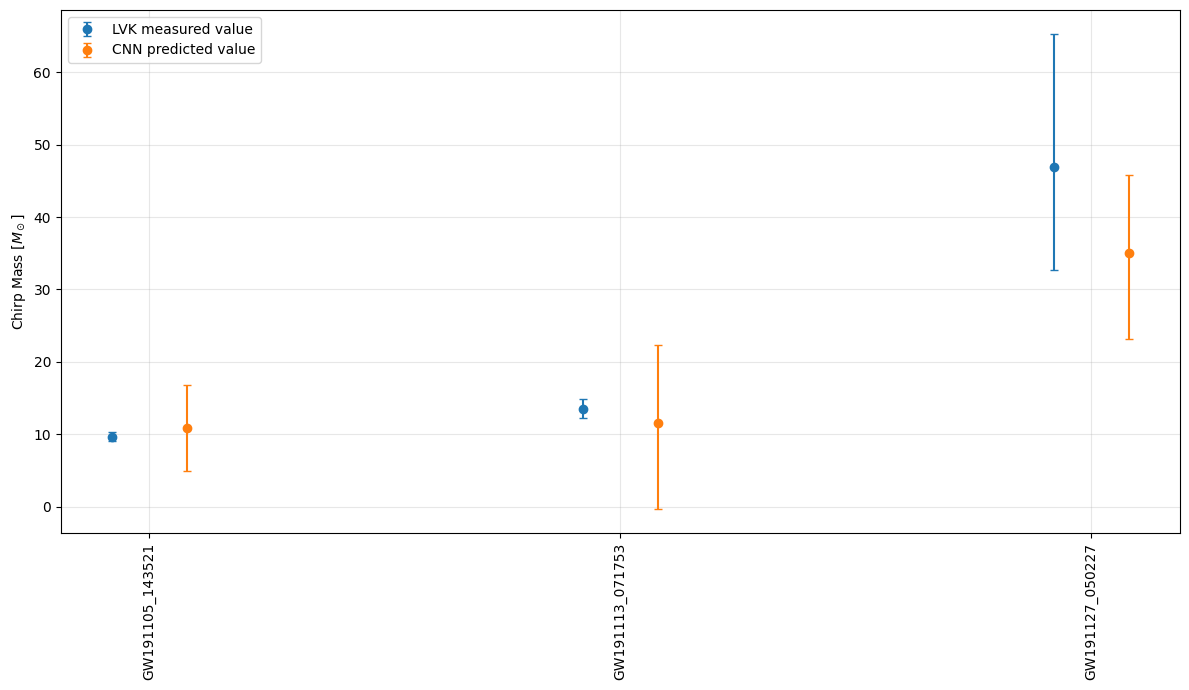

In [60]:
def plot_lvk_vs_cnn_errorbars(
    comparison_df,
    label,
    ylabel,
    sort_by_lvk=True,
    output_path=None,
):
    df = comparison_df.copy()

    required = [
        "event",
        f"{label}_lvk",
        f"{label}_lvk_lower",
        f"{label}_lvk_upper",
        f"{label}_cnn",
        f"{label}_cnn_lower",
        f"{label}_cnn_upper",
    ]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    df = df.dropna(subset=required).copy()

    if df.empty:
        raise ValueError("No complete rows available for plotting.")

    if sort_by_lvk:
        df = df.sort_values(f"{label}_lvk").reset_index(drop=True)

    x = np.arange(len(df))

    lvk_y = df[f"{label}_lvk"].values
    lvk_yerr = np.vstack([
        lvk_y - df[f"{label}_lvk_lower"].values,
        df[f"{label}_lvk_upper"].values - lvk_y,
    ])

    cnn_y = df[f"{label}_cnn"].values
    cnn_yerr = np.vstack([
        cnn_y - df[f"{label}_cnn_lower"].values,
        df[f"{label}_cnn_upper"].values - cnn_y,
    ])

    plt.figure(figsize=(12, 7))

    plt.errorbar(
        x - 0.08,
        lvk_y,
        yerr=lvk_yerr,
        fmt="o",
        capsize=3,
        label="LVK measured value",
    )

    plt.errorbar(
        x + 0.08,
        cnn_y,
        yerr=cnn_yerr,
        fmt="o",
        capsize=3,
        label="CNN predicted value",
    )

    plt.xticks(x, df["event"].values, rotation=90)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=200)
        print("Saved:", output_path)

    plt.show()


plot_lvk_vs_cnn_errorbars(
    comparison_df=comparison_multi_small_df,
    label="chirp_mass",
    ylabel=r"Chirp Mass [$M_\odot$]",
    sort_by_lvk=True,
    output_path=OUTPUT_DIR / "lvk_vs_cnn_chirp_mass_small.png",
)